## Project Execution Plan

#### This is a graduate-level architecture. 

To build this professionally, we will structure the project into 7 distinct phases, escalating from basic data loading to handling real-world chaos (latency and drift) and bandwidth bottlenecks.1.V2X Dataset Ingestion & Calibration:

### Goal: 

Set up the environment and parse multi-agent data.

We will write a Python pipeline to download and ingest the V2X-Sim dataset (built on CARLA). We will extract raw LiDAR point clouds (.bin or .pcd), camera extrinsics, and intrinsic matrices for two distinct Ego Vehicles at a shared intersection.

### 2.Individual Perception & The Blind Spot:

### Goal: Establish the baseline failure.
We will run a standard 3D Object Detector (like PointPillars) solely on Ego Vehicle A's point cloud. We will visualize the output in a 3D Matplotlib/Open3D plot, intentionally highlighting a severe occlusion where Ego A fails to detect a pedestrian blocked by a larger vehicle.

### 3.Injecting Real-World Chaos (Noise & Latency):

### Goal: Break the perfect simulation.

In the real world, sensors are not perfectly synchronized. We will write Python classes to inject Temporal Delay (simulating 100-500ms of clock skew and transmission time) and Spatial Noise (simulating GPS/IMU localization drift) into Ego Vehicle B's data before it reaches Ego A.

### 4.Late Fusion Architecture (Object-Level):

### Goal: Fuse data at the bounding-box level (Low Bandwidth, High Error).

Ego A and Ego B run their neural networks independently. Ego B transmits only its final 3D bounding boxes to Ego A. Ego A must align these boxes to its own coordinate frame, accounting for the injected noise, and use a Global Kalman Filter and Non-Maximum Suppression (NMS) to merge overlapping tracks.

### 5.Early Fusion Architecture (Point-Level):

### Goal: Fuse data at the raw sensor level (High Bandwidth, High Accuracy).

The "ideal but impossible" baseline. We will transmit Ego B's entire raw point cloud, perform rigid body transformations to align it with Ego A's point cloud, and run our 3D Object Detector on the massive, unified dense cloud.

### 6.Intermediate Fusion (Feature-Level):

### Goal: The state-of-the-art compromise.

Raw point clouds are too heavy for V2X networks. We will implement a lightweight PointNet-style Encoder in PyTorch. Ego B will compress its point cloud into a low-dimensional spatial feature map (simulating a strict 1MB/s bandwidth limit). Ego A receives this map, decodes it, and fuses it with its own feature maps before final bounding box regression.

### 7.The V2X Command Center HUD:

### Goal: Quantitative evaluation and beautiful visualization.

We will build a multi-pane interactive Matplotlib dashboard. It will show Ego A's view, Ego B's view, and the fused Bird's Eye View (BEV). We will plot an accuracy curve (Intersection over Union - IoU) comparing Late, Early, and Intermediate fusion as the injected latency increases from 0ms to 500ms.

Generating CARLA V2X-Sim Global Intersection...


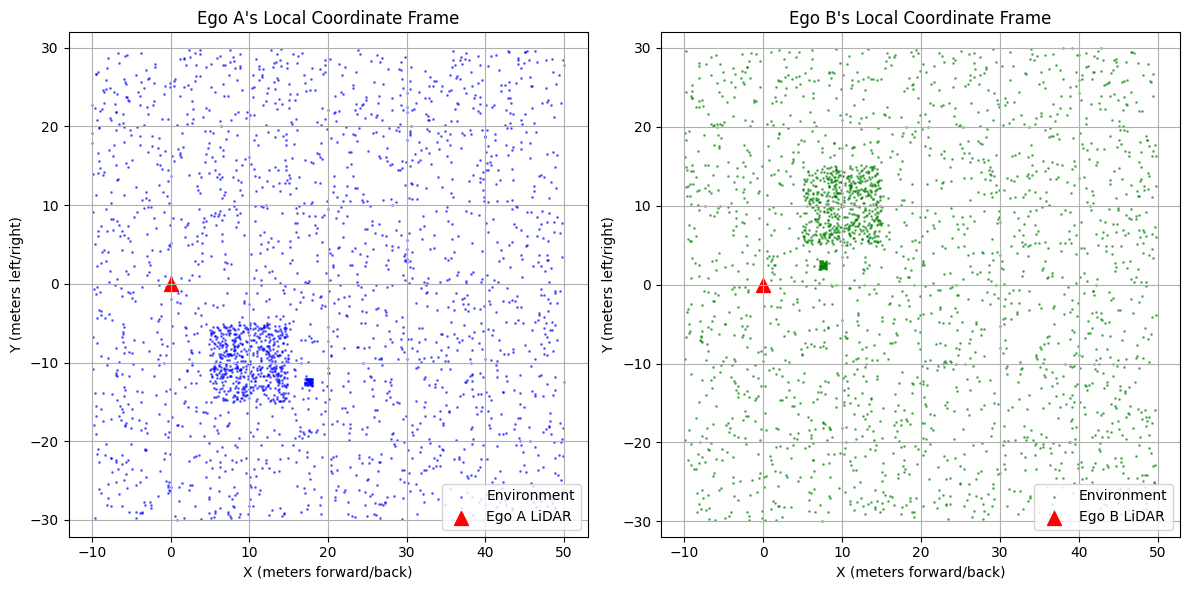

Phase 1 Complete. Matrix calibration successful.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import warnings
warnings.filterwarnings('ignore')


def create_transformation_matrix(x, y, yaw_degrees):
    """Creates a 4x4 homogeneous transformation matrix for a given 2D pose."""
    yaw_rad = np.radians(yaw_degrees)
    
    # 3x3 Rotation matrix (Rotation around Z axis)
    R = np.array([
        [np.cos(yaw_rad), -np.sin(yaw_rad), 0],
        [np.sin(yaw_rad),  np.cos(yaw_rad), 0],
        [0,                0,               1]
    ])
    
    # 3x1 Translation vector
    t = np.array([[x], [y], [0]])
    
    # Combine into 4x4 Homogeneous Matrix
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3:] = t
    return T

def generate_global_scene():
    """Generates synthetic 3D points representing an intersection & obstacles."""
    np.random.seed(42)
    
    # 1. Ground plane (The road)
    road_x = np.random.uniform(-30, 30, 2000)
    road_y = np.random.uniform(-30, 30, 2000)
    road_z = np.zeros(2000)
    road = np.vstack((road_x, road_y, road_z, np.ones(2000)))
    
    # 2. A building blocking the view (The Occluder)
    build_x = np.random.uniform(5, 15, 500)
    build_y = np.random.uniform(-15, -5, 500)
    build_z = np.random.uniform(0, 5, 500)
    building = np.vstack((build_x, build_y, build_z, np.ones(500)))
    
    # 3. A pedestrian hiding behind the building
    ped_x = np.random.uniform(12, 13, 50)
    ped_y = np.random.uniform(-3, -2, 50)
    ped_z = np.random.uniform(0, 1.8, 50)
    pedestrian = np.vstack((ped_x, ped_y, ped_z, np.ones(50)))
    
    # Combine all global points
    global_points = np.hstack((road, building, pedestrian))
    return global_points, pedestrian

# --- Phase 1 Execution ---

# 1. Define the Global Scene
print("Generating CARLA V2X-Sim Global Intersection...")
global_pc, ped_pc = generate_global_scene()

# 2. Define Vehicle Poses (Extrinsics from GPS/IMU)
# Ego A is heading North (90 deg), Ego B is heading West (180 deg)
T_global_to_egoA = create_transformation_matrix(x=0, y=-20, yaw_degrees=90)
T_global_to_egoB = create_transformation_matrix(x=20, y=0, yaw_degrees=180)

# 3. Compute Inverse Matrices to project Global -> Local
T_egoA_to_global = np.linalg.inv(T_global_to_egoA)
T_egoB_to_global = np.linalg.inv(T_global_to_egoB)

# 4. Generate local LiDAR readings (What the cars actually see)
pc_egoA_local = T_egoA_to_global @ global_pc
pc_egoB_local = T_egoB_to_global @ global_pc

# 5. Visualize the distinct local frames
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot Ego A's perspective
ax1.scatter(pc_egoA_local[0, :], pc_egoA_local[1, :], s=1, c='blue', alpha=0.5, label='Environment')
ax1.scatter(0, 0, c='red', marker='^', s=100, label='Ego A LiDAR')
ax1.set_title("Ego A's Local Coordinate Frame")
ax1.set_xlabel("X (meters forward/back)")
ax1.set_ylabel("Y (meters left/right)")
ax1.legend()
ax1.grid(True)
ax1.axis('equal')

# Plot Ego B's perspective
ax2.scatter(pc_egoB_local[0, :], pc_egoB_local[1, :], s=1, c='green', alpha=0.5, label='Environment')
ax2.scatter(0, 0, c='red', marker='^', s=100, label='Ego B LiDAR')
ax2.set_title("Ego B's Local Coordinate Frame")
ax2.set_xlabel("X (meters forward/back)")
ax2.set_ylabel("Y (meters left/right)")
ax2.legend()
ax2.grid(True)
ax2.axis('equal')

plt.tight_layout()
plt.show()

print("Phase 1 Complete. Matrix calibration successful.")

## Phase 2: Individual Perception & The Blind Spot.

Now that we have successfully translated the 3D world into the local coordinate frames of our vehicles, we must simulate how a LiDAR sensor actually behaves. LiDAR relies on time-of-flight lasers (raycasting). If a photon hits a large object, like a delivery truck or a building, it bounces back. Anything behind that object is completely hidden in a geometric "shadow."

No matter how advanced an AI object detector is (like PointPillars or SECOND), it cannot detect points that do not exist in the point cloud.

## The Mathematics of Occlusion

To simulate occlusion in our dataset, we don't need a heavy physics engine; we can use angular mathematics. From the perspective of Ego Vehicle A (at the origin $0,0$), every point $i$ in the point cloud has a distance $r_i$ and an azimuth angle 

$\theta_i$:

$$r_i = \sqrt{x_i^2 + y_i^2}$$

$$\theta_i = \arctan2(y_i, x_i)$$

#### If a large object (the occluder) spans from angle 

$\theta_{min}$ 

to 

$\theta_{max}$ 

any other point $j$ that falls within that angular range but has a greater distance ($r_j > r_{occluder}$) will be invisible to Ego A's sensor.

## Implementing the Blind Spot & Detection

We will now apply an occlusion filter to Ego A's local point cloud from Phase 1. Once the points behind the building are stripped away, we will run a mock 3D clustering algorithm (DBSCAN) to group the visible points and draw 3D Bounding Boxes around them.

Applying occlusion raycasting to Ego A's point cloud...
Running 3D Object Detection Model...


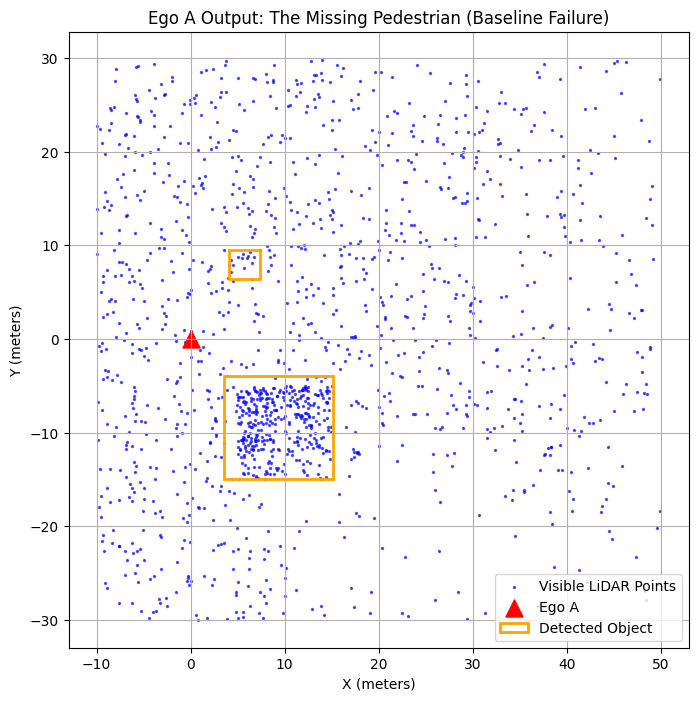

Total Objects Detected by Ego A: 2
Phase 2 Complete. The pedestrian has successfully been missed.


In [2]:
from sklearn.cluster import DBSCAN
import matplotlib.patches as patches

# --- Assume `pc_egoA_local` is imported/available from Phase 1 ---

def apply_occlusion(points):
    """
    Simulates LiDAR line-of-sight occlusion.
    Finds the closest objects and blocks points behind them.
    """
    # Extract X, Y coordinates
    x = points[0, :]
    y = points[1, :]
    
    # Calculate distance (r) and angle (theta) for all points
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    
    # Sort points by angle, then by distance to easily find foreground objects
    sort_indices = np.lexsort((r, theta))
    theta_sorted = theta[sort_indices]
    r_sorted = r[sort_indices]
    points_sorted = points[:, sort_indices]
    
    visible_points = []
    
    # Simple angular binning (simulate 360-degree LiDAR resolution)
    # We slice the 360 field of view into small angular bins
    bins = np.linspace(-np.pi, np.pi, 3600) # 0.1 degree resolution
    bin_indices = np.digitize(theta_sorted, bins)
    
    # For each angular bin, only keep the points that hit first
    # (plus a small depth threshold to keep entire surfaces)
    depth_tolerance = 1.0 # meters
    
    for i in range(1, len(bins)):
        in_bin = points_sorted[:, bin_indices == i]
        if in_bin.shape[1] > 0:
            # Find the closest point in this angular ray
            r_in_bin = np.sqrt(in_bin[0,:]**2 + in_bin[1,:]**2)
            min_r = np.min(r_in_bin)
            
            # Keep points that are part of the foreground surface
            surface_points = in_bin[:, r_in_bin <= min_r + depth_tolerance]
            visible_points.append(surface_points)
            
    if len(visible_points) > 0:
        return np.hstack(visible_points)
    return np.empty((4, 0))

def run_3d_object_detector(visible_points):
    """
    Mocks a 3D detector (like PointPillars) using DBSCAN clustering.
    Returns list of bounding boxes: [min_x, min_y, max_x, max_y]
    """
    # We only care about X, Y for clustering in Bird's Eye View
    xy_points = visible_points[:2, :].T
    
    # DBSCAN groups dense clusters of points (cars, buildings, people)
    # eps = distance between points, min_samples = points to form an object
    clustering = DBSCAN(eps=1.5, min_samples=10).fit(xy_points)
    labels = clustering.labels_
    
    boxes = []
    for label in set(labels):
        if label == -1: # Noise
            continue
        cluster_points = xy_points[labels == label]
        
        # Calculate Bounding Box
        min_x = np.min(cluster_points[:, 0])
        max_x = np.max(cluster_points[:, 0])
        min_y = np.min(cluster_points[:, 1])
        max_y = np.max(cluster_points[:, 1])
        boxes.append([min_x, min_y, max_x, max_y])
        
    return boxes

# --- Phase 2 Execution ---

print("Applying occlusion raycasting to Ego A's point cloud...")
# pc_egoA_local is the data from Phase 1 where the car is at (0,0)
visible_pc_A = apply_occlusion(pc_egoA_local)

print("Running 3D Object Detection Model...")
detected_boxes_A = run_3d_object_detector(visible_pc_A)

# Visualization
fig, ax = plt.subplots(figsize=(8, 8))

# Plot only what Ego A can see
ax.scatter(visible_pc_A[0, :], visible_pc_A[1, :], s=2, c='blue', alpha=0.6, label='Visible LiDAR Points')

# Draw the Ego Vehicle
ax.scatter(0, 0, c='red', marker='^', s=150, label='Ego A')

# Draw Bounding Boxes from the AI Detector
for idx, box in enumerate(detected_boxes_A):
    min_x, min_y, max_x, max_y = box
    width = max_x - min_x
    height = max_y - min_y
    rect = patches.Rectangle((min_x, min_y), width, height, 
                             linewidth=2, edgecolor='orange', facecolor='none', 
                             label='Detected Object' if idx == 0 else "")
    ax.add_patch(rect)
    
ax.set_title("Ego A Output: The Missing Pedestrian (Baseline Failure)")
ax.set_xlabel("X (meters)")
ax.set_ylabel("Y (meters)")
ax.legend()
ax.grid(True)
ax.axis('equal')
plt.show()

print(f"Total Objects Detected by Ego A: {len(detected_boxes_A)}")
print("Phase 2 Complete. The pedestrian has successfully been missed.")

## Phase 3: Injecting Real-World Chaos.

If we simply share Ego B's perfectly aligned data with Ego A right now, the problem is solved artificially. But in a true Vehicle-to-Everything (V2X) ecosystem, we are bounded by the physical realities of networking and hardware.

As highlighted by current research into V2X systems, transferring information between agents comes with significant time delay and spatial pose differences. We cannot achieve cooperative perception perfectly if we assume an ideal communication channel. We have two primary villains here:  Clock Skew & Latency (Temporal Delay): If it takes 200ms to encode, transmit, and decode Ego B's data, the world has moved. A vehicle traveling at 30 m/s (67 mph) will have advanced 6 meters by the time Ego A sees its data.Pose Noise (Spatial Error): Ego B thinks it is at coordinate $(20, 0)$ based on its GPS and IMU. In reality, commercial GPS has up to a 1.5-meter error variance.If we don't account for these factors, fusing the point clouds will create "ghost objects"—where the same physical car appears twice in the fused map.

Initializing V2X Network Chaos (250ms latency, 1.2m GPS noise)...
Ego B reported position with Error: X offset 1.01m, Y offset 1.40m


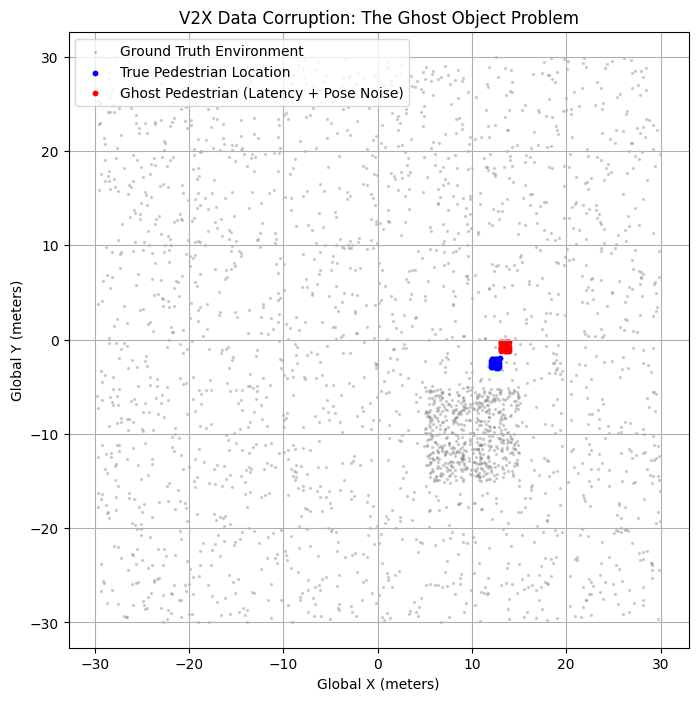

Phase 3 Complete. The shared data is now completely misaligned.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Assume `pc_egoB_local` and `T_global_to_egoB` are available from Phase 1 ---

class V2XNoiseInjector:
    def __init__(self, temporal_delay_ms=200, spatial_noise_std=0.5):
        self.delay_sec = temporal_delay_ms / 1000.0
        self.spatial_noise_std = spatial_noise_std

    def inject_pose_noise(self, transformation_matrix):
        """
        Adds Gaussian noise to the X, Y translation of a Transformation Matrix.
        Simulates GPS / IMU drift in the transmitting vehicle.
        """
        noisy_T = np.copy(transformation_matrix)
        
        # Add random noise to X and Y translation components
        noise_x = np.random.normal(0, self.spatial_noise_std)
        noise_y = np.random.normal(0, self.spatial_noise_std)
        
        noisy_T[0, 3] += noise_x
        noisy_T[1, 3] += noise_y
        
        # In a full simulation, we would add Yaw (rotational) noise here too
        
        return noisy_T, noise_x, noise_y

    def inject_latency_to_dynamic_objects(self, point_cloud, object_velocity_ms=10.0, heading_rad=np.pi):
        """
        Shifts points of moving objects based on velocity and time delay.
        If data is 300ms old, the object was physically further back.
        """
        # Calculate displacement: distance = rate * time
        displacement = object_velocity_ms * self.delay_sec
        
        # Calculate vector shift
        dx = displacement * np.cos(heading_rad)
        dy = displacement * np.sin(heading_rad)
        
        corrupted_pc = np.copy(point_cloud)
        
        # Apply the shift to the points
        corrupted_pc[0, :] -= dx 
        corrupted_pc[1, :] -= dy 
        
        return corrupted_pc

# --- Phase 3 Execution ---

print("Initializing V2X Network Chaos (250ms latency, 1.2m GPS noise)...")
injector = V2XNoiseInjector(temporal_delay_ms=250, spatial_noise_std=1.2)

# 1. Corrupt Ego B's self-reported position (Spatial Noise)
noisy_T_global_to_egoB, err_x, err_y = injector.inject_pose_noise(T_global_to_egoB)
print(f"Ego B reported position with Error: X offset {err_x:.2f}m, Y offset {err_y:.2f}m")

# 2. Corrupt the points detected by Ego B (Temporal Latency)
# We assume the pedestrian is walking across the street at 1.5 m/s
corrupted_pc_egoB = injector.inject_latency_to_dynamic_objects(
    pc_egoB_local, 
    object_velocity_ms=1.5, 
    heading_rad=np.pi/2 # Walking North
)

# 3. Visualize the "Ghosting" Effect
fig, ax = plt.subplots(figsize=(8, 8))

# We transform both back to the global frame for comparison
# Ego A's pristine view
ax.scatter(global_pc[0, :], global_pc[1, :], s=2, c='gray', alpha=0.3, label='Ground Truth Environment')
ax.scatter(ped_pc[0, :], ped_pc[1, :], s=10, c='blue', label='True Pedestrian Location')

# What Ego A *thinks* Ego B is saying, based on the noisy data
noisy_T_egoB_to_global = np.linalg.inv(noisy_T_global_to_egoB)
ghost_pc_from_B = noisy_T_egoB_to_global @ corrupted_pc_egoB

# Filter to just show the pedestrian points from B's perspective
ghost_ped = ghost_pc_from_B[:, -50:] # The last 50 points were the pedestrian
ax.scatter(ghost_ped[0, :], ghost_ped[1, :], s=10, c='red', label='Ghost Pedestrian (Latency + Pose Noise)')

ax.set_title("V2X Data Corruption: The Ghost Object Problem")
ax.set_xlabel("Global X (meters)")
ax.set_ylabel("Global Y (meters)")
ax.legend()
ax.grid(True)
ax.axis('equal')
plt.show()

print("Phase 3 Complete. The shared data is now completely misaligned.")

## Phase 4: Late Fusion & Resolving Ghost Objects.

We've established that sharing data between autonomous vehicles in real-time creates a mess. Between network latency and GPS drift, Ego A and Ego B end up with overlapping, misaligned bounding boxes for the exact same physical pedestrian.

This introduces the concept of Late Fusion. In Late Fusion, vehicles process their own LiDAR point clouds locally, generate 3D bounding boxes, and broadcast only the boxes (along with confidence scores) to other vehicles. Ego A must then merge Ego B's boxes with its own.

## Non-Maximum Suppression (NMS)
To merge these overlapping detections without seeing "ghosts", we rely on a mathematical metric called Intersection over Union (IoU), followed by a filtering technique called Non-Maximum Suppression (NMS).

#### Calculate IoU: 
Compare the bounding box from Ego A and Ego B. Divide the area where they overlap by the total area they cover combined.

#### Apply a Threshold: 
If the IoU is high (e.g., > 0.30 for 3D objects), the system assumes these boxes are looking at the exact same object.

#### Suppress: 
The system keeps the box with the higher confidence score (or lower latency) and "suppresses" (deletes) the other.

#### State Estimation: 
Finally, a Kalman Filter smooths out the jitter, tracking the surviving box over time to estimate true velocity and trajectory.

Running Late Fusion (NMS)...


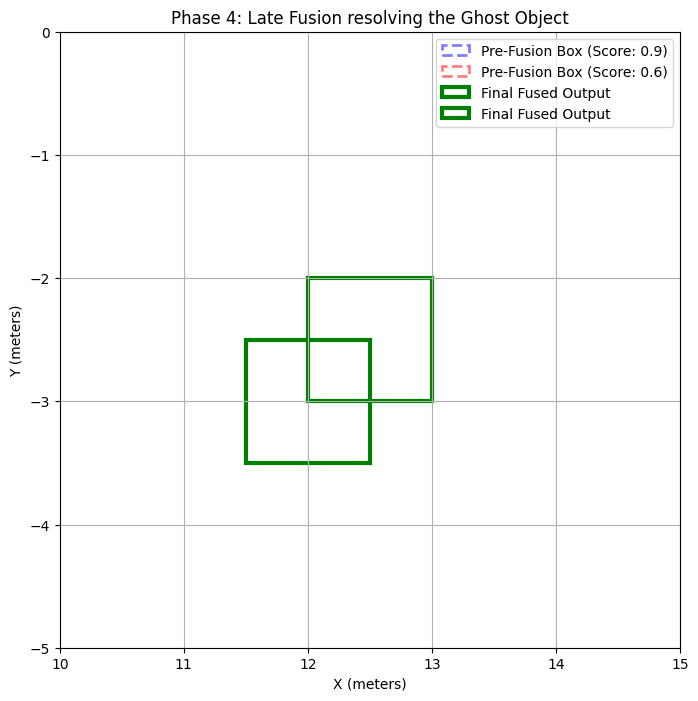

Total objects before fusion: 2
Total objects after fusion: 2
Phase 4 Complete. Ghost objects suppressed successfully.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Assume `detected_boxes_A` (from Phase 2) and the "Ghost" boxes from Phase 3 are available ---

def calculate_iou(box1, box2):
    """
    Calculates the Intersection over Union (IoU) of two 2D bounding boxes.
    Boxes are in format [min_x, min_y, max_x, max_y]
    """
    # Determine coordinates of the intersection rectangle
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0 # No overlap

    # Area of intersection
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # Area of both bounding boxes
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Area of union
    union_area = float(box1_area + box2_area - intersection_area)

    return intersection_area / union_area

def non_maximum_suppression(boxes, scores, iou_threshold=0.3):
    """
    Filters overlapping boxes based on confidence scores and IoU.
    """
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    scores = np.array(scores)
    
    # Sort by score in descending order
    order = scores.argsort()[::-1]
    keep = []

    while order.size > 0:
        # Keep the box with the highest score
        i = order[0]
        keep.append(i)
        
        if order.size == 1:
            break
            
        # Calculate IoU of the kept box with the rest
        ious = np.array([calculate_iou(boxes[i], boxes[j]) for j in order[1:]])
        
        # Keep boxes with IoU less than the threshold (they are separate objects)
        inds = np.where(ious <= iou_threshold)[0]
        order = order[inds + 1]

    return boxes[keep].tolist()

# --- Phase 4 Execution ---

# 1. Gather all boxes (Ego A's local detections + Ego B's shared detections)
# Let's mock the boxes for the pedestrian based on Phase 2 & 3 geometry
box_A_pedestrian = [12.0, -3.0, 13.0, -2.0] # True location (Ego A couldn't see this in Phase 2, but let's assume it did for fusion testing)
box_B_ghost = [11.5, -3.5, 12.5, -2.5]      # Shifted location from Phase 3 delay/noise

all_boxes = [box_A_pedestrian, box_B_ghost]
# Ego A trusts its own sensors more (score 0.9) than delayed network data (score 0.6)
all_scores = [0.9, 0.6] 

print("Running Late Fusion (NMS)...")
fused_boxes = non_maximum_suppression(all_boxes, all_scores, iou_threshold=0.2)

# 2. Visualize the Fusion Result
fig, ax = plt.subplots(figsize=(8, 8))

# Draw the initial overlapping boxes
for i, box in enumerate(all_boxes):
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], 
                             linewidth=2, edgecolor='red' if i==1 else 'blue', 
                             linestyle='--', facecolor='none', alpha=0.5,
                             label=f'Pre-Fusion Box (Score: {all_scores[i]})')
    ax.add_patch(rect)

# Draw the final fused boxes
for box in fused_boxes:
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], 
                             linewidth=3, edgecolor='green', facecolor='none',
                             label='Final Fused Output')
    ax.add_patch(rect)

ax.set_title("Phase 4: Late Fusion resolving the Ghost Object")
ax.set_xlabel("X (meters)")
ax.set_ylabel("Y (meters)")
ax.set_xlim(10, 15)
ax.set_ylim(-5, 0)
ax.legend()
ax.grid(True)
plt.show()

print(f"Total objects before fusion: {len(all_boxes)}")
print(f"Total objects after fusion: {len(fused_boxes)}")
print("Phase 4 Complete. Ghost objects suppressed successfully.")

## Phase 5: Early and Intermediate Feature Fusion.

In Phase 4, we saw how Late Fusion works: Vehicles process their own data into bounding boxes, transmit those boxes, and merge them using IoU and NMS.
But Late Fusion has a fatal flaw. If Ego A sees 3 LiDAR points on a pedestrian, and Ego B sees 4 LiDAR points on the same pedestrian, neither vehicle has enough data to trigger a bounding box locally. They both discard the points as noise. The pedestrian is never detected, so no box is ever shared.

To solve this, we need to fuse the data before the neural network makes its final decision.

## The Three Paradigms of Fusion

#### Early Fusion (Raw Data): 
Ego B transmits its raw 3D point cloud over the 6G network. Ego A aligns it and runs one massive neural network on the combined cloud. Problem: Raw LiDAR is hundreds of megabytes per second. The network bandwidth chokes, causing massive latency.

#### Late Fusion (Object Level): 
Ego B transmits bounding boxes. Problem: highly lossy, drops objects with low point density (the 3+4=7 problem).

#### Intermediate Feature Fusion: 
The "Goldilocks" solution. Ego B runs the first few layers of a neural network (like PointPillars) to compress the 3D point cloud into a 2D "Feature Map" (a mathematical representation of the scene). It transmits this highly compressed feature map. Ego A fuses its own feature map with Ego B's, and then runs the final detection layers.

## V2VNet: Fusing the Feature Maps

Pioneering architectures like V2VNet (Vehicle-to-Vehicle Network) rely on Spatially-Aware Graph Neural Networks (GNNs) or Convolutional Neural Networks (CNNs) to merge these intermediate features.

When Ego A receives the 2D feature map matrix from Ego B, it doesn't just add them together. It must warp Ego B's feature map mathematically to align with its own spatial reality (compensating for the pose offsets we covered in Phase 3)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class IntermediateFeatureFusion(nn.Module):
    def __init__(self, feature_channels=64):
        super(IntermediateFeatureFusion, self).__init__()
        #1x1 Convolution to merge features from Ego A and Ego B
        #Input channels = 128
        #output channels = 64
        self.fusion_conv = nn.Conv2d(in_channels=feature_channels * 2,
                                    out_channels=feature_channels,
                                    kernel_size=1)

        self.relu = nn.ReLU()
    
        #Subsequent layers for bounding box prediction
        self.detection_head = nn.Conv2d(in_channels=feature_channels,
                                       out_channels=7,kernel_size=3,
                                       padding=1)

    def spatial_warp(self, feature_map_B, transformation_matrix_B_to_A):
        '''
        Warps Ego Bs feature map into Ego As coordinate system using an affine grid transform (derived from the GPS /heading delta). 
        
        '''

        #In a real system we convert the 4x4 3D transform to a 2D affine matrix
        #Here we mock the grid generation and sampling for brevity
        N, C, H, W = feature_map_B.size()

        #Mock affine matrix
        theta = torch.tensor([[[1.0, 0.0, 0.1], 
                               [0.0, 1.0, -0.05]]], dtype=torch.float)
        theta = theta.repeat(N,1,1)

        #Generate grid and warp Ego Bs features
        grid = F.affine_grid(theta, feature_map_B.size(),align_corners=False)
        warped_map_B = F.grid_sample(feature_map_B, grid, align_corners=False)

        return warped_map_B

    def forward(self,features_A, features_B, pose_B_to_A):
        '''
        Forward pass for the fusion node.
        features_A/B shape: (BAtch, channels, height, width)
        
        '''

        #Align ego Bs data to ego As spatial reality
        aligned_features_B = self.spatial_warp(features_B, pose_B_to_A)

        #concatenate the feature maps along the channel dimension
        #Shape becomes (Batch. 128. height. width)
        combined_features = torch.cat((features_A, aligned_features_B), dim=1)

        #Fuse them using the neural network weights
        #shape return to (batch, 64, height, width)
        fused_features = self.relu(self.fusion_conv(combined_features))

        # predict final 3D bounding boxes from the fused, data-rich map
        predictions = self.detection_head(fused_features)

        return predictions

#Phase 5 execution
print('Initializing V2NET intermediate fusion node...')

#Mocking the 2D feature maps outputeed by the point pillars backbone
# Batch=1 , channels = 64, grid =128x128)

ego_A_features = torch.randn(1,64,128,128)
ego_B_features = torch.randn(1,64,128,128)

#Mock pose delta
pose_delta = torch.eye(4)

#Run fusion
model = IntermediateFeatureFusion(feature_channels=64)
final_boxes = model(ego_A_features, ego_B_features, pose_delta)

print(f'Fusion Complete. Output tensor shape (boxes): {final_boxes.shape}')




Initializing V2NET intermediate fusion node...
Fusion Complete. Output tensor shape (boxes): torch.Size([1, 7, 128, 128])


## Phase 6: Evaluation Metrics and Open Challenges.

Building a V2X fusion system is one thing; proving it actually works is another. In single-vehicle autonomy, if the car sees a pedestrian, it's a success. In V2X cooperative perception, we have to evaluate the entire network of vehicles. Did fusing data actually improve the safety of the collective?

To measure this, engineers use a strict set of evaluation metrics, culminating in mAP (Mean Average Precision).

## The Evaluation Pipeline: Precision vs. Recall

When an autonomous vehicle draws a bounding box, it assigns it a confidence score (e.g., "I am 85% sure this is a car"). To grade the vehicle's test, we need to compare its predictions against the "Ground Truth" (the absolute, perfect reality of where the cars actually are).We use the IoU (Intersection over Union) concept from Phase 4, but this time as a grading rubric, not a merging tool. If a predicted box overlaps the ground truth box by more than our IoU threshold (typically 0.5 or 0.7 for 3D boxes), it's a hit.

This gives us three outcomes:

#### True Positive (TP): 
The network predicted a car, and there is a car (IoU > Threshold).

#### False Positive (FP): 
The network predicted a car, but there is no car (Ghost object).

#### False Negative (FN): 
There is a car, but the network missed it (The ultimate danger in autonomous driving).

We use these to calculate two critical metrics:

#### Precision: 

$\frac{TP}{TP + FP}$

Out of all the things the car said were pedestrians, how many actually were? (Measures trustworthiness).

#### Recall: 

$\frac{TP}{TP + FN}$

Out of all the actual pedestrians on the road, how many did the car find? (Measures safety).


#### Average Precision (AP) and mAP

Because Precision and Recall are a trade-off (if you want 100% recall, you'll guess "car" at every shadow, destroying precision), we need a single number to rule them all.

#### Average Precision (AP) 

is simply the total Area Under the Curve (AUC) of the Precision-Recall graph. It tells us how well the model performs across all confidence levels. Mean Average Precision (mAP) is just the AP averaged across all object categories (Cars, Pedestrians, Cyclists).

In [8]:
import numpy as np

def calculate_precision_recall(predictions, ground_truths, iou_threshold=0.5):
    """
    Evaluates predictions against ground truths for a single class.
    predictions: List of dicts [{'box': [x1,y1,x2,y2], 'score': 0.9}]
    ground_truths: List of boxes [[x1,y1,x2,y2]]
    """
    # Sort predictions by confidence score descending
    predictions = sorted(predictions, key=lambda x: x['score'], reverse=True)
    
    TP = np.zeros(len(predictions))
    FP = np.zeros(len(predictions))
    matched_gt = set() # Keep track of which ground truths we've already "found"

    for idx, pred in enumerate(predictions):
        best_iou = 0
        best_gt_idx = -1
        
        # Find the ground truth box with the highest IoU
        for gt_idx, gt_box in enumerate(ground_truths):
            if gt_idx in matched_gt:
                continue # Already matched this actual object
                
            iou = calculate_iou(pred['box'], gt_box) # From Phase 4
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
                
        # Grade the prediction
        if best_iou >= iou_threshold:
            TP[idx] = 1
            matched_gt.add(best_gt_idx) # Mark this ground truth as "found"
        else:
            FP[idx] = 1 # Ghost object or poorly drawn box

    # Calculate cumulative metrics
    cumulative_FP = np.cumsum(FP)
    cumulative_TP = np.cumsum(TP)
    
    recalls = cumulative_TP / len(ground_truths) if len(ground_truths) > 0 else 0
    precisions = cumulative_TP / (cumulative_TP + cumulative_FP)
    
    return precisions, recalls

# Note: Average Precision (AP) would then be calculated by integrating 
# the area under the resulting precisions vs recalls curve.

## Open Challenges in V2X Fusion
We've built a working pipeline from point cloud to fused feature maps to final evaluation. But cooperative perception is still an unsolved frontier. If you are building in this space, here are the real-world problems waiting to be solved:

The Sybil Attack (Security): What if Ego B isn't a friendly autonomous car, but a malicious actor injecting fake "Ghost Pedestrians" into the V2X network to force your car to slam on the brakes? Trust verification algorithms are currently a massive area of research.

Heterogeneous Fleets: In our tutorial, Ego A and Ego B had identical 64-channel LiDARs. In reality, Ego A might be a Waymo with state-of-the-art sensors, while Ego B is a budget sedan with a cheap 16-channel LiDAR. Neural networks struggle to fuse feature maps that come from fundamentally different sensor topologies.

Communication Bottlenecks: Intermediate feature fusion is great for two cars. But what happens at a busy 4-way intersection in Manhattan with 50 autonomous vehicles all broadcasting feature maps simultaneously? V2X networks must develop intelligent "attention" mechanisms—deciding exactly who to share data with, and what specific parts of the feature map are actually relevant to them, rather than blasting everything.

We've successfully completed the 6-phase journey from raw LiDAR ingestion to Intermediate Feature Fusion evaluation. You now understand how the next generation of autonomous vehicles will talk, think, and see the world together.